141


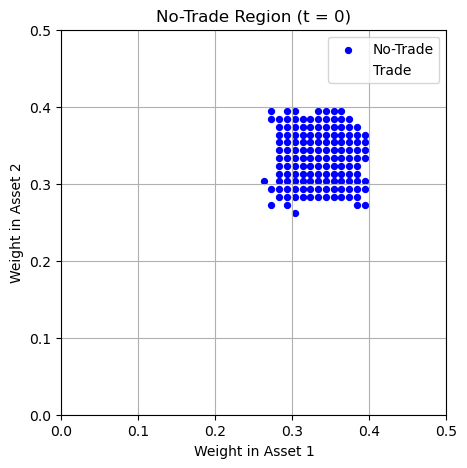

141


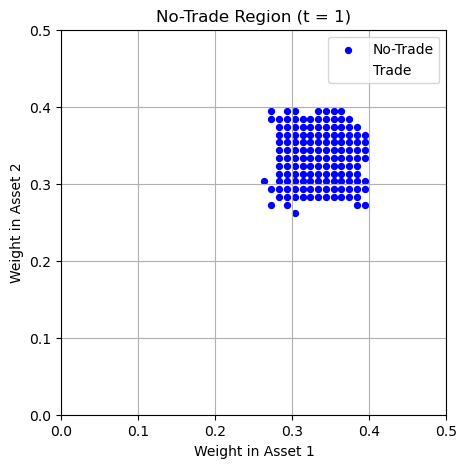

145


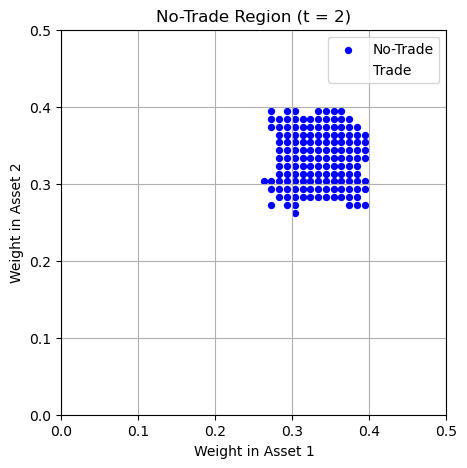

153


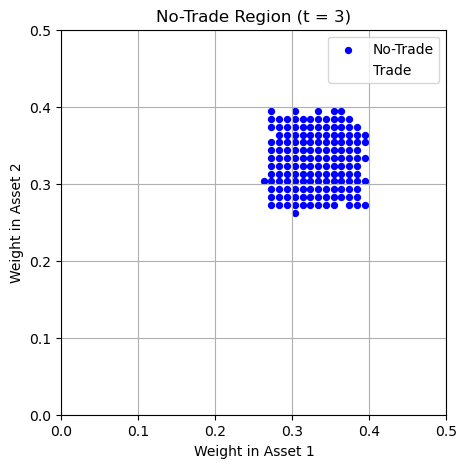

149


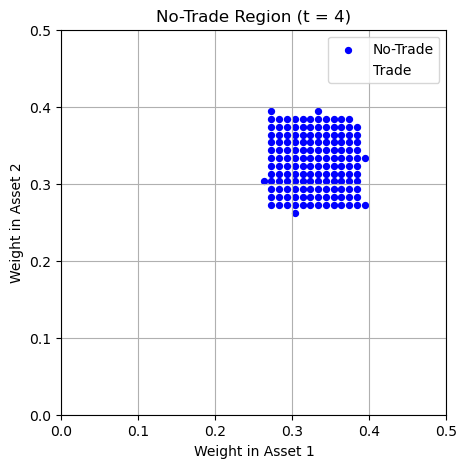

147


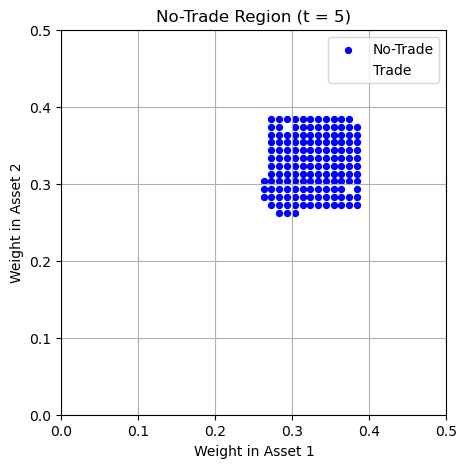

147


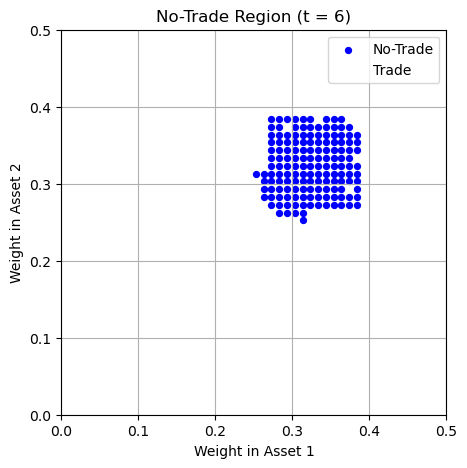

199


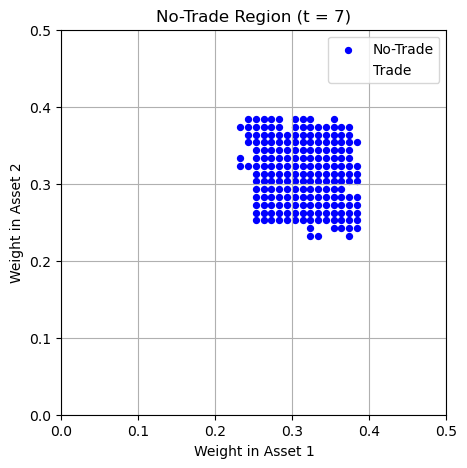

343


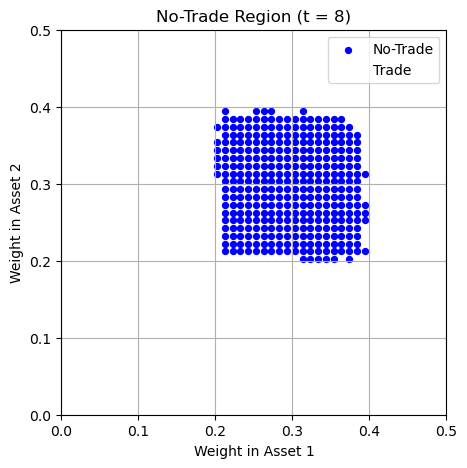

1277


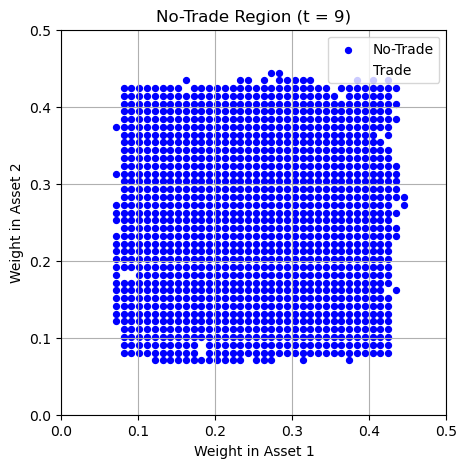

In [ ]:
import numpy as np
import numba as nb
from scipy.special import roots_hermite
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1.  Parameters
# -------------------------------------------------
T      = 10
beta   = 0.97
gamma  = 3
tau    = 0.01
r      = 0.03

mu_vec    = np.array([0.07, 0.07])
sigma_vec = np.array([0.20, 0.20])
rho       = 0.0
Sigma     = np.array([[sigma_vec[0]**2, rho*sigma_vec[0]*sigma_vec[1]],
                      [rho*sigma_vec[0]*sigma_vec[1], sigma_vec[1]**2]])
Lchol     = np.linalg.cholesky(Sigma).astype(np.float64)        # ensure 64-bit

@nb.njit(cache=True)
def util(c,gamma): 
    '''CRRA utility function'''
    if gamma!=1:
        return (c**(1-gamma))/(1-gamma)
    else:
        return np.log(c)   


# -------------------------------------------------
# 2.  Discretisations
# -------------------------------------------------
n_grid  = 100
w_vals  = np.linspace(0.0, 1.0, n_grid)
grid_w  = np.array([(w1, w2)
                    for w1 in w_vals
                    for w2 in w_vals
                    if w1 + w2 <= 1.0], dtype=np.float64)
n_states = grid_w.shape[0]

# --- fast index table: (i, j) on the n_grid×n_grid lattice → state-index
w_map = -np.ones((n_grid, n_grid), dtype=np.int64)
for k, (w1, w2) in enumerate(grid_w):
    i = int(round(w1*(n_grid-1)))
    j = int(round(w2*(n_grid-1)))
    w_map[i, j] = k                      # every feasible pair is unique

# -------------------------------------------------
# 3.  2-D Gaussian-Hermite rule
# -------------------------------------------------
n_q         = 5
z1d, w1d    = roots_hermite(n_q)
gh_nodes    = np.array([(z1, z2) for z1 in z1d for z2 in z1d], dtype=np.float64)
gh_weights  = np.array([wx*wy          for wx in w1d for wy in w1d], dtype=np.float64)
n_quad      = gh_nodes.shape[0]



# -------------------------------------------------
# 4.  Numba kernels
# -------------------------------------------------
@nb.njit
def exp_continuation_numba(w1p, w2p, Vnext,
                           gh_nodes, gh_weights,
                           mu_vec, L, w_map, n_grid,
                           gamma, r, b_t):
    """
    Computes   E_t[ V_{t+1}(w') · R^{1-γ} ]  at weights (w1p,w2p).
    All arrays are already 64-bit, so no copies inside Numba.
    """
    wf   = b_t
    acc  = 0.0

    for q in range(n_quad):
        z1, z2 = gh_nodes[q, 0], gh_nodes[q, 1]

        # correlated simple returns: μ + √2 L z
        R0 = mu_vec[0] + np.sqrt(2.0)*(L[0,0]*z1 + L[0,1]*z2)
        R1 = mu_vec[1] + np.sqrt(2.0)*(L[1,0]*z1 + L[1,1]*z2)
        g0 = 1.0 + R0
        g1 = 1.0 + R1
        if g0 <= 0.0 or g1 <= 0.0:
            continue

        denom = w1p*g0 + w2p*g1 + wf*(1.0+r)
        w1n   = (w1p*g0)/denom
        w2n   = (w2p*g1)/denom

        # nearest grid point (round onto lattice, then fix if outside simplex)
        i = int(round(w1n*(n_grid-1)))
        j = int(round(w2n*(n_grid-1)))
        s = i + j
        if s > (n_grid-1):             # project back to simplex boundary
            w1n /= w1n + w2n
            w2n  = 1.0 - w1n
            i = int(round(w1n*(n_grid-1)))
            j = int(round(w2n*(n_grid-1)))

        idx = w_map[i, j]
        acc += gh_weights[q] * Vnext[idx] * denom**(1.0 - gamma)

    return acc / np.pi                 # 2-D Hermite scaling


@nb.njit(fastmath=True, cache=True)
def bond_weight_numba(x1, x2, x1n, x2n, tau):
    # NB: all inputs must already be np.float64 arrays or scalars
    trade_cost = tau * (np.abs(x1n - x1) + np.abs(x2n - x2))
    b_t   = 1.0 - x1n - x2n - trade_cost
    return b_t


@nb.njit(parallel=True)
def solve_model(T, grid_w, gh_nodes, gh_weights, mu_vec, L,
                beta, gamma, tau, r,
                w_map, n_grid):
    n_states = grid_w.shape[0]
    V = np.zeros((T+1, n_states), dtype=np.float64)
    A = np.zeros((T,   n_states, 2), dtype=np.float64)

    # terminal value
    for s in range(n_states):
        w1, w2 = grid_w[s, 0], grid_w[s, 1]
        cons   = 1.0 - tau*(w1 + w2)              # net consumption at T
        if cons > 0.0:                            # well-defined utility
            V[T, s] = util(cons,gamma)
        else:                                     # infeasible ⇒ very bad
            V[T, s] = -1.0e30

    for t in range(T-1, -1, -1):                 # T-1, …, 0
        Vnext = V[t+1]
        # outer loop parallelised across current states
        for s in nb.prange(n_states):
            w1, w2  = grid_w[s, 0], grid_w[s, 1]

            best_val = -1e30
            best_w1p = w1
            best_w2p = w2

            # feasible trades lie on the same simplex grid
            for a in range(n_states):
                w1p, w2p = grid_w[a, 0], grid_w[a, 1]
                if w1p + w2p > 1.0:
                    continue

                trade = abs(w1p - w1) + abs(w2p - w2)
                cf    = 1.0 - tau*trade                # after fee
                if cf <= 0.0:
                    continue
                bond_weight = bond_weight_numba(w1, w2, w1p, w2p, tau)
                cont = exp_continuation_numba(w1p, w2p, Vnext,
                                              gh_nodes, gh_weights,
                                              mu_vec, L, w_map, n_grid,
                                              gamma, r, bond_weight)
                val = (cf**(1.0 - gamma)) * beta * cont

                if val > best_val:
                    best_val = val
                    best_w1p = w1p
                    best_w2p = w2p

            V[t, s]    = best_val
            A[t, s, 0] = best_w1p
            A[t, s, 1] = best_w2p

    return V, A


# -------------------------------------------------
# 5.  Solve and check speed
# -------------------------------------------------
V_opt, A_opt = solve_model(T, grid_w, gh_nodes, gh_weights, mu_vec, Lchol,
                           beta, gamma, tau, r,
                           w_map, n_grid)

# (plotting of NTR is identical to your original script and can
#  reuse V_opt / A_opt directly)
for t in range(T):
    # current grid
    w1a = grid_w[:, 0]
    w2a = grid_w[:, 1]

    # “no–trade’’ indicator (vectorised, tolerance 1 e-12)
    no_trade = (np.isclose(A_opt[t, :, 0], w1a, atol=1e-12) &
                np.isclose(A_opt[t, :, 1], w2a, atol=1e-12))

    plt.figure(figsize=(5, 5))
    print(len(w1a[no_trade]))
    plt.scatter(w1a[no_trade],   w2a[no_trade],   c='blue',   s=18, label='No-Trade')
    plt.scatter(w1a[~no_trade],  w2a[~no_trade],  c='white', marker='x', s=18, label='Trade')
    plt.title(f'No-Trade Region (t = {t})')
    plt.xlabel('Weight in Asset 1'); plt.ylabel('Weight in Asset 2')
    plt.xlim(0, 0.5); plt.ylim(0, 0.5); plt.gca().set_aspect('equal')
    plt.grid()
    plt.legend(); plt.show()


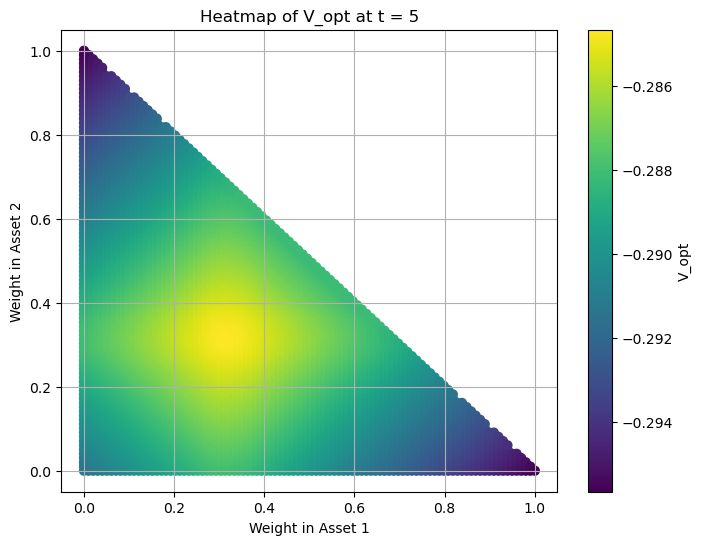

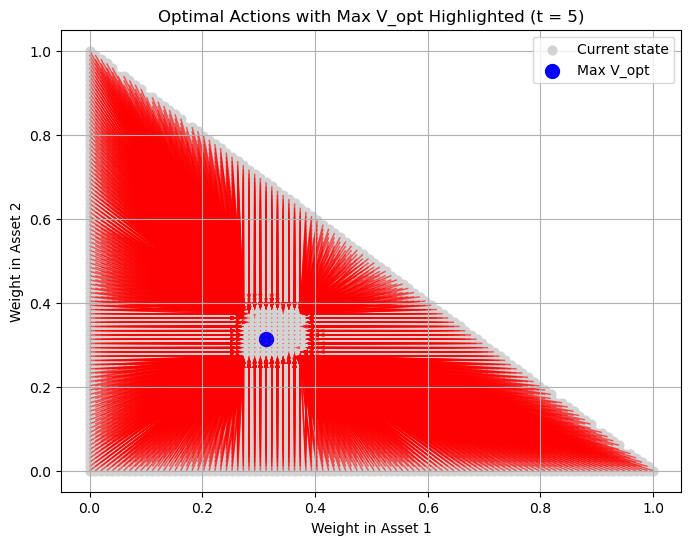

In [161]:
# Choose the time step for analysis
t_plot = 5

# ---------------------------
# 1. Create a heatmap of V_opt at time t_plot
# ---------------------------
plt.figure(figsize=(8,6))
sc = plt.scatter(grid_w[:,0], grid_w[:,1], c=V_opt[t_plot, :], cmap="viridis", s=40)
plt.colorbar(sc, label="V_opt")
plt.xlabel("Weight in Asset 1")
plt.ylabel("Weight in Asset 2")
plt.title(f"Heatmap of V_opt at t = {t_plot}")
plt.grid(True)
plt.show()


# ---------------------------
# 3. Mark the state with the highest V_opt
# ---------------------------
max_idx = np.argmax(V_opt[t_plot, :])

plt.figure(figsize=(8,6))
plt.scatter(grid_w[:,0], grid_w[:,1], c="lightgray", s=40, label="Current state")
plt.scatter([grid_w[max_idx,0]], [grid_w[max_idx,1]], c="blue", s=100, marker="o", label="Max V_opt")
plt.quiver(grid_w[:,0], grid_w[:,1],
           A_opt[t_plot,:,0] - grid_w[:,0],
           A_opt[t_plot,:,1] - grid_w[:,1],
           angles='xy', scale_units='xy', scale=1, color='red', alpha=0.6)
plt.xlabel("Weight in Asset 1")
plt.ylabel("Weight in Asset 2")
plt.title(f"Optimal Actions with Max V_opt Highlighted (t = {t_plot})")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import time
n_grid_values = [20, 40, 60, 80, 100]

timings = {}
for n_grid_val in n_grid_values:
    # Rebuild discretisation for current n_grid
    w_vals = np.linspace(0.0, 1.0, n_grid_val)
    grid_w = np.array([(w1, w2) for w1 in w_vals for w2 in w_vals if w1 + w2 <= 1.0], dtype=np.float64)
    n_states = grid_w.shape[0]

    # Build fast index table: (i, j) on the n_grid x n_grid lattice maps to state index
    w_map = -np.ones((n_grid_val, n_grid_val), dtype=np.int64)
    for k, (w1, w2) in enumerate(grid_w):
        i = int(round(w1*(n_grid_val - 1)))
        j = int(round(w2*(n_grid_val - 1)))
        w_map[i, j] = k

    # Time the solve_model function call
    start = time.perf_counter()
    V_opt, A_opt = solve_model(T, grid_w, gh_nodes, gh_weights, mu_vec, Lchol,
                               beta, gamma, tau, r,
                               w_map, n_grid_val)
    elapsed = time.perf_counter() - start
    timings[n_grid_val] = elapsed
    print(f"n_grid = {n_grid_val} (total states = {n_states}), time taken: {elapsed:.4f} seconds")
print("Timing results:", timings)


NameError: name 'solve_model' is not defined

In [ ]:
# -------------------------------------------------
# 1.  Parameters
# -------------------------------------------------
T      = 11
beta   = 0.97
gamma  = 3
tau    = 0.005
r      = 0.03

mu_vec    = np.array([0.07, 0.07])
sigma_vec = np.array([0.20, 0.20])
rho       = 0.0
Sigma     = np.array([[sigma_vec[0]**2, rho*sigma_vec[0]*sigma_vec[1]],
                      [rho*sigma_vec[0]*sigma_vec[1], sigma_vec[1]**2]])
Lchol     = np.linalg.cholesky(Sigma).astype(np.float64)        # ensure 64-bit


def util_nnb(c,gamma): 
    '''CRRA utility function'''
    if gamma!=1:
        return (c**(1-gamma))/(1-gamma)
    else:
        return np.log(c)   


# -------------------------------------------------
# 2.  Discretisations
# -------------------------------------------------
n_grid  = 20
w_vals  = np.linspace(0.0, 1.0, n_grid)
grid_w  = np.array([(w1, w2)
                    for w1 in w_vals
                    for w2 in w_vals
                    if w1 + w2 <= 1.0], dtype=np.float64)
n_states = grid_w.shape[0]

# --- fast index table: (i, j) on the n_grid×n_grid lattice → state-index
w_map = -np.ones((n_grid, n_grid), dtype=np.int64)
for k, (w1, w2) in enumerate(grid_w):
    i = int(round(w1*(n_grid-1)))
    j = int(round(w2*(n_grid-1)))
    w_map[i, j] = k                      # every feasible pair is unique


def exp_continuation(w1p, w2p, Vnext,
                           gh_nodes, gh_weights,
                           mu_vec, L, w_map, n_grid,
                           gamma, r,bond):
    """
    Computes   E_t[ V_{t+1}(w') · R^{1-γ} ]  at weights (w1p,w2p).
    """
    acc  = 0.0

    for q in range(n_quad):
        z1, z2 = gh_nodes[q, 0], gh_nodes[q, 1]

        # correlated simple returns: μ + √2 L z
        R0 = mu_vec[0] + np.sqrt(2.0)*(L[0,0]*z1 + L[0,1]*z2)
        R1 = mu_vec[1] + np.sqrt(2.0)*(L[1,0]*z1 + L[1,1]*z2)
        g0 = 1.0 + R0
        g1 = 1.0 + R1
        if g0 <= 0.0 or g1 <= 0.0:
            continue

        denom = w1p*g0 + w2p*g1 + bond*(1.0+r)
        w1n   = (w1p*g0)/denom
        w2n   = (w2p*g1)/denom

        # nearest grid point (round onto lattice, then fix if outside simplex)
        i = int(round(w1n*(n_grid-1)))
        j = int(round(w2n*(n_grid-1)))
        s = i + j
        if s > (n_grid-1):             # project back to simplex boundary
            w1n /= w1n + w2n
            w2n  = 1.0 - w1n
            i = int(round(w1n*(n_grid-1)))
            j = int(round(w2n*(n_grid-1)))

        idx = w_map[i, j]
        acc += gh_weights[q] * Vnext[idx] * denom**(1.0 - gamma)

    return acc / np.pi                 # 2-D Hermite scaling



def bond_weight(x1, x2, x1n, x2n, tau):
    # NB: all inputs must already be np.float64 arrays or scalars
    trade_cost = tau * (np.abs(x1n - x1) + np.abs(x2n - x2))
    b_t   = 1.0 - x1n - x2n - trade_cost
    return b_t



def solve_model_nnb(T, grid_w, gh_nodes, gh_weights, mu_vec, L,
                beta, gamma, tau, r,
                w_map, n_grid):
    n_states = grid_w.shape[0]
    V = np.zeros((T+1, n_states), dtype=np.float64)
    A = np.zeros((T,   n_states, 2), dtype=np.float64)

    # terminal value
    for s in range(n_states):
        w1, w2 = grid_w[s, 0], grid_w[s, 1]
        cons   = 1.0 - tau*(w1 + w2)              # net consumption at T
        if cons > 0.0:                            # well-defined utility
            V[T, s] = util_nnb(cons,gamma)
        else:                                     # infeasible ⇒ very bad
            V[T, s] = -1.0e30

    for t in range(T-1, -1, -1):                 # T-1, …, 0
        Vnext = V[t+1]
        # outer loop parallelised across current states
        for s in range(n_states):
            w1, w2  = grid_w[s, 0], grid_w[s, 1]

            best_val = -1e30
            best_w1p = w1
            best_w2p = w2

            # feasible trades lie on the same simplex grid
            for a in range(n_states):
                w1p, w2p = grid_w[a, 0], grid_w[a, 1]
                if w1p + w2p > 1.0:
                    continue

                trade = abs(w1p - w1) + abs(w2p - w2)
                cf    = 1.0 - tau*trade                # after fee
                if cf <= 0.0:
                    continue
                bond_holdings = bond_weight(w1, w2, w1p, w2p, tau)
                cont = exp_continuation(w1p, w2p, Vnext,
                                              gh_nodes, gh_weights,
                                              mu_vec, L, w_map, n_grid,
                                              gamma, r, bond_holdings)
                val = (cf**(1.0 - gamma)) * beta * cont

                if val > best_val:
                    best_val = val
                    best_w1p = w1p
                    best_w2p = w2p

            V[t, s]    = best_val
            A[t, s, 0] = best_w1p
            A[t, s, 1] = best_w2p

    return V, A

In [ ]:
n_grid_values = [5, 10, 20, 25, 30, 40]

timings = {}
for n_grid_val in n_grid_values:
    # Rebuild discretisation for current n_grid
    w_vals = np.linspace(0.0, 1.0, n_grid_val)
    grid_w = np.array([(w1, w2) for w1 in w_vals for w2 in w_vals if w1 + w2 <= 1.0], dtype=np.float64)
    n_states = grid_w.shape[0]

    # Build fast index table: (i, j) on the n_grid x n_grid lattice maps to state index
    w_map = -np.ones((n_grid_val, n_grid_val), dtype=np.int64)
    for k, (w1, w2) in enumerate(grid_w):
        i = int(round(w1*(n_grid_val - 1)))
        j = int(round(w2*(n_grid_val - 1)))
        w_map[i, j] = k

    # Time the solve_model function call
    start = time.perf_counter()
    V_opt, A_opt = solve_model_nnb(T, grid_w, gh_nodes, gh_weights, mu_vec, Lchol,
                               beta, gamma, tau, r,
                               w_map, n_grid_val)
    elapsed = time.perf_counter() - start
    timings[n_grid_val] = elapsed
    print(f"n_grid = {n_grid_val} (total states = {n_states}), time taken: {elapsed:.4f} seconds")
print("Timing results:", timings)

n_grid = 5 (total states = 15), time taken: 0.5753 seconds
n_grid = 10 (total states = 55), time taken: 7.9971 seconds

Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)

n_grid = 20 (total states = 210), time taken: 119.3413 seconds
n_grid = 25 (total states = 325), time taken: 280.1394 seconds
n_grid = 30 (total states = 465), time taken: 581.9898 seconds
n_grid = 40 (total states = 820), time taken: 1836.1368 seconds
Timing results: {5: 0.5753124000038952, 10: 7.997092200035695, 20: 119.34126400004607, 25: 280.1394025000045, 30: 581.9897907999693, 40: 1836.13680019998}


In [113]:
import numpy as np
import time
import matplotlib.pyplot as plt
from itertools import product
from scipy.special import roots_hermite

# -------------------------------------------------
# Fixed model parameters
# -------------------------------------------------
T      = 10           # number of periods
beta   = 0.97
gamma  = 3
r      = 0.03

# -------------------------------------------------
# Parameter grids (for tau ≠ 0.0001)
# -------------------------------------------------
mu_list    = [np.array([0.06, 0.06]), np.array([0.07, 0.07]), np.array([0.05, 0.05]), np.array([0.08, 0.08]), np.array([0.04, 0.04])]
sigma_list = [np.array([0.17, 0.17]), np.array([0.20, 0.20]), np.array([0.15, 0.15]), np.array([0.20, 0.20]), np.array([0.12, 0.12]), np.array([0.25, 0.25])]
tau_list   = [0.01]    
rho_list   = [0.0]

# -------------------------------------------------
# Discretisation for the state space
# -------------------------------------------------
n_grid = 100
w_vals = np.linspace(0.0, 1.0, n_grid)
grid_w = np.array([(w1, w2) for w1 in w_vals 
                     for w2 in w_vals if w1 + w2 <= 1.0], dtype=np.float64)
n_states = grid_w.shape[0]

# Build fast index table for the grid
w_map = -np.ones((n_grid, n_grid), dtype=np.int64)
for k, (w1, w2) in enumerate(grid_w):
    i = int(round(w1*(n_grid-1)))
    j = int(round(w2*(n_grid-1)))
    w_map[i, j] = k

# -------------------------------------------------
# Gaussian-Hermite quadrature
# -------------------------------------------------
n_q      = 5
z1d, w1d = roots_hermite(n_q)
gh_nodes    = np.array([(z1, z2) for z1 in z1d for z2 in z1d], dtype=np.float64)
gh_weights  = np.array([wx*wy for wx in w1d for wy in w1d], dtype=np.float64)
n_quad      = gh_nodes.shape[0]

# -------------------------------------------------
# Training data container
# -------------------------------------------------
training_data = []
tol = 1e-12

# --- Part 1: Run model for tau values ≠ 0.0001 (append full record) ---
# --- Part 1: Run model for tau values ≠ 0.0001 (append full record) ---
for mu_vec, sigma_vec, tau_val, rho in product(mu_list, sigma_list, tau_list, rho_list):
    # Build covariance matrix and its Cholesky factor
    Sigma = np.array([[sigma_vec[0]**2, rho*sigma_vec[0]*sigma_vec[1]],
                      [rho*sigma_vec[0]*sigma_vec[1], sigma_vec[1]**2]])
    Lchol = np.linalg.cholesky(Sigma).astype(np.float64)
    
    print(f"\nSolving model for: mu={mu_vec}, sigma={sigma_vec}, tau={tau_val}, rho={rho}")
    start = time.perf_counter()
    V_opt, A_opt = solve_model(T, grid_w, gh_nodes, gh_weights, mu_vec, Lchol,
                               beta, gamma, tau_val, r, w_map, n_grid)
    runtime = time.perf_counter() - start
    print(f"Runtime: {runtime:.4f} sec, Total states: {n_states}")
    
    # For each decision period, append full training record
    for t in range(T-1):
        NTR_binary = np.array([
            1 if (np.isclose(A_opt[t, s, 0], grid_w[s, 0], atol=tol) and 
                  np.isclose(A_opt[t, s, 1], grid_w[s, 1], atol=tol))
            else 0 for s in range(n_states)
        ])
        optimal_idx = np.where(
            np.isclose(A_opt[t, :, 0], grid_w[:, 0], atol=tol) &
            np.isclose(A_opt[t, :, 1], grid_w[:, 1], atol=tol)
        )[0]
        optimal_weights = grid_w[optimal_idx]
        training_data.append({
            'mu': mu_vec.copy(),
            'sigma': sigma_vec.copy(),
            'tau': tau_val,
            'rho': rho,
            'time': t,
            'grid': grid_w.copy(),
            'NTR': NTR_binary.copy(),
            'V_opt': V_opt[t, :].copy(),
            'A_opt': A_opt[t, :, :].copy(),
            'optimal_weights': optimal_weights.copy(),
            'runtime': runtime,
            'record_type': 'full'
        })


Solving model for: mu=[0.06 0.06], sigma=[0.17 0.17], tau=0.01, rho=0.0
Runtime: 23.9691 sec, Total states: 5044

Solving model for: mu=[0.06 0.06], sigma=[0.2 0.2], tau=0.01, rho=0.0
Runtime: 23.0204 sec, Total states: 5044

Solving model for: mu=[0.06 0.06], sigma=[0.15 0.15], tau=0.01, rho=0.0
Runtime: 23.9496 sec, Total states: 5044

Solving model for: mu=[0.06 0.06], sigma=[0.2 0.2], tau=0.01, rho=0.0
Runtime: 24.4354 sec, Total states: 5044

Solving model for: mu=[0.06 0.06], sigma=[0.12 0.12], tau=0.01, rho=0.0
Runtime: 24.6926 sec, Total states: 5044

Solving model for: mu=[0.06 0.06], sigma=[0.25 0.25], tau=0.01, rho=0.0
Runtime: 23.4075 sec, Total states: 5044

Solving model for: mu=[0.07 0.07], sigma=[0.17 0.17], tau=0.01, rho=0.0
Runtime: 24.0556 sec, Total states: 5044

Solving model for: mu=[0.07 0.07], sigma=[0.2 0.2], tau=0.01, rho=0.0
Runtime: 25.8756 sec, Total states: 5044

Solving model for: mu=[0.07 0.07], sigma=[0.15 0.15], tau=0.01, rho=0.0
Runtime: 27.5271 sec,

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt
from itertools import product
from scipy.special import roots_hermite

# -------------------------------------------------
# Fixed model parameters
# -------------------------------------------------
T      = 10           # number of periods
beta   = 0.97
gamma  = 3
r      = 0.03

# -------------------------------------------------
# Parameter grids (for tau ≠ 0.0001)
# -------------------------------------------------
mu_list    = [np.array([0.065, 0.065])]
sigma_list = [np.array([0.18, 0.18])]
tau_list   = [0.01]    # tau values other than 0.0001
rho_list   = [0.0]

# -------------------------------------------------
# Discretisation for the state space
# -------------------------------------------------
n_grid = 100
w_vals = np.linspace(0.0, 1.0, n_grid)
grid_w = np.array([(w1, w2) for w1 in w_vals 
                     for w2 in w_vals if w1 + w2 <= 1.0], dtype=np.float64)
n_states = grid_w.shape[0]

# Build fast index table for the grid
w_map = -np.ones((n_grid, n_grid), dtype=np.int64)
for k, (w1, w2) in enumerate(grid_w):
    i = int(round(w1*(n_grid-1)))
    j = int(round(w2*(n_grid-1)))
    w_map[i, j] = k

# -------------------------------------------------
# Gaussian-Hermite quadrature
# -------------------------------------------------
n_q      = 5
z1d, w1d = roots_hermite(n_q)
gh_nodes    = np.array([(z1, z2) for z1 in z1d for z2 in z1d], dtype=np.float64)
gh_weights  = np.array([wx*wy for wx in w1d for wy in w1d], dtype=np.float64)
n_quad      = gh_nodes.shape[0]

# -------------------------------------------------
# Training data container
# -------------------------------------------------
test_data = []
tol = 1e-12

# --- Part 1: Run model for tau values ≠ 0.0001 (append full record) ---
for mu_vec, sigma_vec, tau_val, rho in product(mu_list, sigma_list, tau_list, rho_list):
    # Build covariance matrix and its Cholesky factor
    Sigma = np.array([[sigma_vec[0]**2, rho*sigma_vec[0]*sigma_vec[1]],
                      [rho*sigma_vec[0]*sigma_vec[1], sigma_vec[1]**2]])
    Lchol = np.linalg.cholesky(Sigma).astype(np.float64)
    
    print(f"\nSolving model for: mu={mu_vec}, sigma={sigma_vec}, tau={tau_val}, rho={rho}")
    start = time.perf_counter()
    V_opt, A_opt = solve_model(T, grid_w, gh_nodes, gh_weights, mu_vec, Lchol,
                               beta, gamma, tau_val, r, w_map, n_grid)
    runtime = time.perf_counter() - start
    print(f"Runtime: {runtime:.4f} sec, Total states: {n_states}")
    
    # For each decision period, append full training record
    for t in range(T-1):
        NTR_binary = np.array([
            1 if (np.isclose(A_opt[t, s, 0], grid_w[s, 0], atol=tol) and 
                  np.isclose(A_opt[t, s, 1], grid_w[s, 1], atol=tol))
            else 0 for s in range(n_states)
        ])
        optimal_idx = np.where(
            np.isclose(A_opt[t, :, 0], grid_w[:, 0], atol=tol) &
            np.isclose(A_opt[t, :, 1], grid_w[:, 1], atol=tol)
        )[0]
        optimal_weights = grid_w[optimal_idx]
        test_data.append({
            'mu': mu_vec.copy(),
            'sigma': sigma_vec.copy(),
            'tau': tau_val,
            'rho': rho,
            'time': t,
            'grid': grid_w.copy(),
            'NTR': NTR_binary.copy(),
            'V_opt': V_opt[t, :].copy(),
            'A_opt': A_opt[t, :, :].copy(),
            'optimal_weights': optimal_weights.copy(),
            'runtime': runtime,
            'record_type': 'full'
        })


Solving model for: mu=[0.065 0.065], sigma=[0.18 0.18], tau=0.01, rho=0.0
Runtime: 26.5339 sec, Total states: 5044


In [157]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

class NTRDataset(Dataset):
    def __init__(self, training_data):
        # We only use records of type 'full'
        self.samples = []
        for rec in training_data:
            t = rec['time']
            mu = rec['mu']   # shape (2,)
            sigma = rec['sigma'] # shape (2,)
            NTR = rec['NTR']
            w_opt = rec['optimal_weights']
            split = round(len(w_opt)/2)
            optimal_weights = w_opt[split]
            x = np.concatenate(([t], mu, sigma, optimal_weights))
            y = NTR.flatten()
            self.samples.append((x.astype(np.float32), y.astype(np.float32)))

                    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        return self.samples[idx]


class NTRNet(nn.Module):
    def __init__(self, input_dim=7, hidden_sizes=[40,40,40,40]):
        super(NTRNet, self).__init__()
        layers = []
        in_dim = input_dim
        output_dim = dataset[0][1].shape[0]        # 5044 in your case
        for hidden in hidden_sizes:
            layers.append(nn.Linear(in_dim, hidden))
            layers.append(nn.ReLU())
            in_dim = hidden
        layers.append(nn.Linear(in_dim, output_dim))
        self.model = nn.Sequential(*layers)
        
    def forward(self, x):
        return torch.sigmoid(self.model(x))


def train_ntr_model(model, dataset, epochs=10, batch_size=128, lr=1e-4):
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * X_batch.size(0)
        avg_loss = total_loss/len(dataset)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")
    return model

# Example usage:
if __name__ == '__main__':
    # Assume training_data is already built in your workspace
    # For example, training_data is a list of dictionaries.
    dataset = NTRDataset(training_data)
    model = NTRNet()
    trained_model = train_ntr_model(model, dataset, epochs=1000, batch_size=4, lr=1e-3)

Epoch 1/1000, Loss: 0.415560
Epoch 2/1000, Loss: 0.146685
Epoch 3/1000, Loss: 0.124112
Epoch 4/1000, Loss: 0.113244
Epoch 5/1000, Loss: 0.104960
Epoch 6/1000, Loss: 0.104135
Epoch 7/1000, Loss: 0.102763
Epoch 8/1000, Loss: 0.102920
Epoch 9/1000, Loss: 0.104448
Epoch 10/1000, Loss: 0.101973
Epoch 11/1000, Loss: 0.101795
Epoch 12/1000, Loss: 0.100701
Epoch 13/1000, Loss: 0.101651
Epoch 14/1000, Loss: 0.100854
Epoch 15/1000, Loss: 0.101838
Epoch 16/1000, Loss: 0.101274
Epoch 17/1000, Loss: 0.099995
Epoch 18/1000, Loss: 0.100808
Epoch 19/1000, Loss: 0.099768
Epoch 20/1000, Loss: 0.099911
Epoch 21/1000, Loss: 0.099623
Epoch 22/1000, Loss: 0.100118
Epoch 23/1000, Loss: 0.099395
Epoch 24/1000, Loss: 0.098965
Epoch 25/1000, Loss: 0.099128
Epoch 26/1000, Loss: 0.098971
Epoch 27/1000, Loss: 0.098584
Epoch 28/1000, Loss: 0.098156
Epoch 29/1000, Loss: 0.098857
Epoch 30/1000, Loss: 0.099311
Epoch 31/1000, Loss: 0.097535
Epoch 32/1000, Loss: 0.099491
Epoch 33/1000, Loss: 0.097701
Epoch 34/1000, Loss

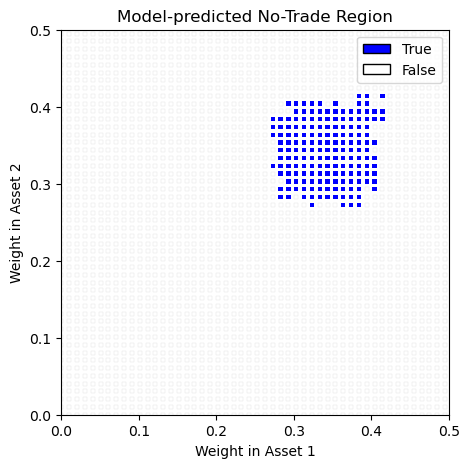

In [159]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Set filter parameters (as built in your training/testing records)
tau_filter = 0.01
time_filter = 5
mu = np.array([0.065, 0.065])
sigma = np.array([0.18, 0.18])

# Locate a matching record from test_data using your filtering criteria.
for rec in test_data:
    if (rec['record_type'] == 'full' and 
        rec['tau'] == tau_filter and 
        rec['time'] == time_filter and 
        np.array_equal(rec['mu'], mu) and 
        np.array_equal(rec['sigma'], sigma)):
        t_val = rec['time']
        grid = rec['grid']          # shape: (n_states, 2)
        actual_NTR = rec['NTR']     # binary vector (n_states,)
        w_opt = rec['optimal_weights']
        # Take the middle of w_opt as optimal_weights
        split = round(len(w_opt)/2)
        optimal_weights = w_opt[split]
        break

n_states = grid.shape[0]

# Build the feature matrix X:
# Each sample is: [t, mu[0], mu[1], sigma[0], sigma[1], optimal_weights[0], optimal_weights[1]]
x = np.array([[t_val,
               mu[0], mu[1],
               sigma[0], sigma[1],
               optimal_weights[0], optimal_weights[1]]],  # shape (1, 7)
             dtype=np.float32)

# Convert X to tensor and get predictions
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
x_tensor = torch.from_numpy(x).to(device)

trained_model.eval()
with torch.no_grad():
    preds = trained_model(x_tensor)          # shape (1, 5 044)
preds = preds.cpu().numpy().squeeze(0)       # → shape (5 044,)
# Convert predicted probabilities to binary labels using a threshold
preds_binary = (preds >= 0.5)

from matplotlib.patches import Patch

# ── 2. scatter: False → white, True → blue ─────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(grid[~preds_binary, 0],        # False first (background)
           grid[~preds_binary, 1],
           marker='s', s=10,
           c='white', edgecolor='lightgrey', linewidth=0.2)

ax.scatter(grid[preds_binary, 0],         # True overlay in blue
           grid[preds_binary, 1],
           marker='s', s=10,
           c='blue', edgecolor='none')

ax.set_xlim(0, 0.5)                     
ax.set_ylim(0, 0.5)
ax.set_xlabel('Weight in Asset 1')
ax.set_ylabel('Weight in Asset 2')
ax.set_title('Model-predicted No-Trade Region')

# tidy legend
ax.legend(handles=[
    Patch(facecolor='blue',  edgecolor='k', label='True'),
    Patch(facecolor='white', edgecolor='k', label='False')
], loc='upper right')

plt.show()

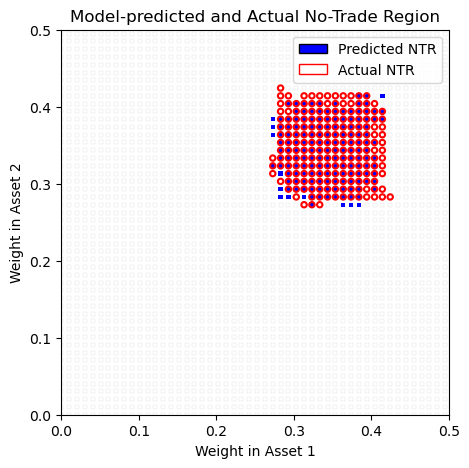

In [163]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(5, 5))

# Plot predicted NTR: False (background) in white, True in blue
ax.scatter(grid[~preds_binary, 0],        # predicted False (Trade region)
           grid[~preds_binary, 1],
           marker='s', s=10,
           c='white', edgecolor='lightgrey', linewidth=0.2)
ax.scatter(grid[preds_binary, 0],         # predicted True (No-Trade region)
           grid[preds_binary, 1],
           marker='s', s=10,
           c='blue', edgecolor='none')

# Overlay actual NTR: plot states where actual NTR is True with red circles
actual_mask = actual_NTR.astype(bool)
ax.scatter(grid[actual_mask, 0],
           grid[actual_mask, 1],
           marker='o', s=15,
           facecolors='none', edgecolors='red', linewidth=1.5, label='Actual NTR')

ax.set_xlim(0, 0.5)                     
ax.set_ylim(0, 0.5)
ax.set_xlabel('Weight in Asset 1')
ax.set_ylabel('Weight in Asset 2')
ax.set_title('Model-predicted and Actual No-Trade Region')

# Tidy legend
ax.legend(handles=[
    Patch(facecolor='blue', edgecolor='k', label='Predicted NTR'),
    Patch(facecolor='none', edgecolor='red', label='Actual NTR')
], loc='upper right')

plt.show()

